In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

from ft_engineering import load_and_prep_data

# --- Función 1: Construir Pipeline de Modelo ---
def build_model(model_instance, preprocessor):
    return Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model_instance)
    ])

# --- Función 2: Resumen de Métricas de Clasificación ---
def summarize_classification(y_true, y_pred, y_proba=None, model_name="Modelo"):
    metrics = {
        'Modelo': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0)
    }
    if y_proba is not None:
        metrics['ROC-AUC'] = roc_auc_score(y_true, y_proba)
    return metrics

In [2]:
# Cargar conjuntos de train/test y preprocesador
X_train, X_test, y_train, y_test, preprocessor = load_and_prep_data()

# Definir diccionario de modelos candidatos
modelos = {
    'Regresión Logística': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

resultados = []
modelos_entrenados = {}

# Entrenamiento y evaluación iterativa
for nombre, algoritmo in modelos.items():
    pipe = build_model(algoritmo, preprocessor)
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else None
    
    res = summarize_classification(y_test, y_pred, y_proba, model_name=nombre)
    resultados.append(res)
    modelos_entrenados[nombre] = (pipe, y_proba)

# Tabla Resumen de Evaluación
df_resumen = pd.DataFrame(resultados).set_index('Modelo')
display(df_resumen)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Regresión Logística,0.952624,0.952624,1.000000,0.975737,0.619306
Random Forest,0.951695,0.953423,0.998050,0.975226,0.587509
XGBoost,0.950302,0.954206,0.995612,0.974469,0.585809


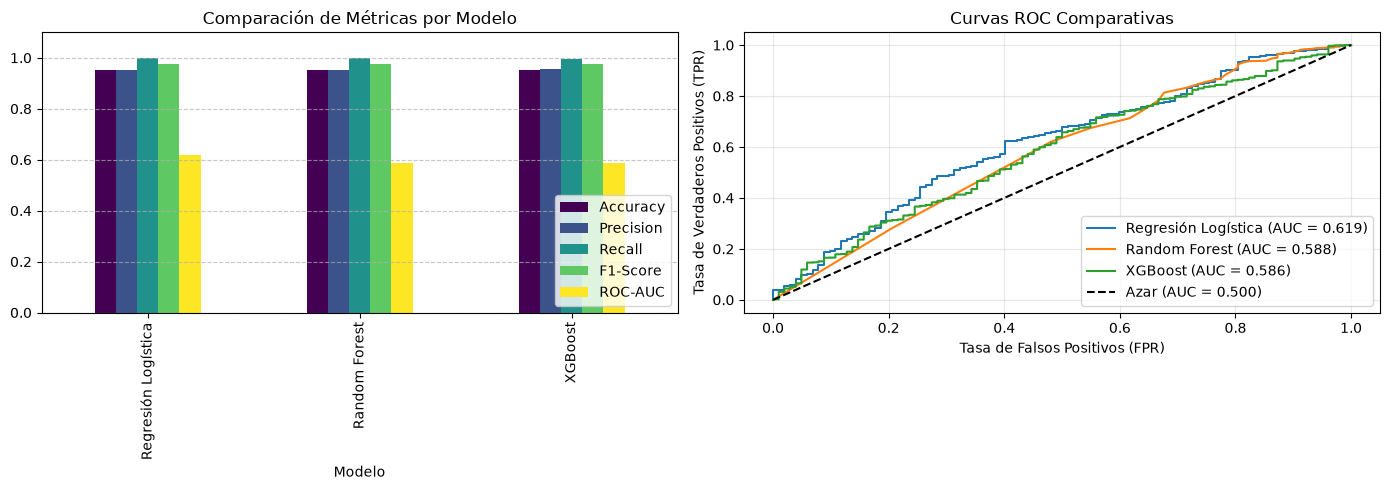

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gráfico de Barras de Métricas Comparativas
df_resumen.plot(kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title('Comparación de Métricas por Modelo')
axes[0].set_ylim(0, 1.1)
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 2. Curvas ROC Comparativas
for nombre, (pipe, y_proba) in modelos_entrenados.items():
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        axes[1].plot(fpr, tpr, label=f'{nombre} (AUC = {auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', label='Azar (AUC = 0.500)')
axes[1].set_title('Curvas ROC Comparativas')
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()